# GradPath Dublin · Career-Readiness Agent

**COMP47980 · Generative AI and Language Models · Project 2026**

An LLM-based assistant for international Master's-level Computer Science students preparing for graduate / junior software engineering roles in Dublin.


This notebook builds and runs a domain-specific agent on top of OpenAI's Responses API. The agent uses all three Responses-API tools — **File Search**, **Function Calling**, and **Code Interpreter** — and integrates **three external APIs**: GitHub REST, Greenhouse Job Boards, and The Muse.

Run cells in order. Sections are clearly marked.

## Prerequisites

Before running, configure these Colab secrets :

- `OPENAI_API_KEY` — your OpenAI API key
- `GITHUB_TOKEN` — a GitHub personal access token (scope: public_repo, optional but increases rate limit)

Greenhouse and The Muse are used without authentication — both are public APIs.

## Cost estimate

Running this notebook end-to-end including all worked examples typically costs under €0.8 in OpenAI usage when using `gpt-4.1`.

---
## Section 1 · Setup

Install dependencies, mount Google Drive, configure clients.

In [3]:
!pip install openai --quiet

from openai import OpenAI
from google.colab import userdata
import os, json, time, requests
from datetime import date, datetime, timezone
from pathlib import Path

# Clone the project repository (knowledge base + supporting files)
# This makes the notebook self-contained — no Drive setup required.
GITHUB_REPO = 'https://github.com/YibenZhou25/gradpath-dublin.git'
REPO_DIR = '/content/gradpath-dublin/gradpath_knowledge_base'

if not os.path.isdir(REPO_DIR):
    !git clone {GITHUB_REPO} {REPO_DIR}
else:
    print(f'✓ Repository already cloned at {REPO_DIR}')

# Load secrets
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
try:
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    GITHUB_TOKEN = None
    print('⚠ No GITHUB_TOKEN found — GitHub API calls will use unauthenticated rate limit (60/hr)')

client = OpenAI()

KB_ROOT = f'{REPO_DIR}/gradpath_knowledge_base'
MODEL = 'gpt-4.1'

# Verify the knowledge base is present
kb_files_count = sum(1 for sub in os.listdir(KB_ROOT)
                     if os.path.isdir(os.path.join(KB_ROOT, sub)))
print(f'✓ OpenAI client ready')
print(f'✓ Knowledge base cloned at: {KB_ROOT}')
print(f'✓ Found {kb_files_count} category folders in KB')
print(f'✓ Model: {MODEL}')

Cloning into '/content/gradpath-dublin/gradpath_knowledge_base'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 49 (delta 1), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 2.84 MiB | 10.50 MiB/s, done.
Resolving deltas: 100% (1/1), done.
✓ OpenAI client ready
✓ Knowledge base cloned at: /content/gradpath-dublin/gradpath_knowledge_base/gradpath_knowledge_base
✓ Found 6 category folders in KB
✓ Model: gpt-4.1


---
## Section 2 · Vector Store · File Search backbone

Upload the curated knowledge base into an OpenAI vector store. The agent retrieves chunks from this store at conversation time using the File Search tool.



In [4]:
# Cache stored in /content (ephemeral) — vector store will be recreated each session.
# This is intentional: the new clone path doesn't have persistent state, and
# the OpenAI vector store costs nothing to recreate from indexed files.
VECTOR_STORE_CACHE = '/content/.gradpath_vector_store_id'
def collect_kb_files():
    """Walk the knowledge base and return all .md and .pdf files."""
    files = []
    valid_extensions = ('.md', '.pdf')
    for sub in ['00_meta', '01_companies', '02_interviews', '03_rubrics',
                '04_visa_and_market', '05_cultural']:
        sub_path = os.path.join(KB_ROOT, sub)
        if not os.path.isdir(sub_path):
            continue
        for fname in sorted(os.listdir(sub_path)):
            # Skip templates and hidden files
            if fname.startswith('_template') or fname.startswith('.'):
                continue
            if fname.endswith(valid_extensions):
                files.append(os.path.join(sub_path, fname))
    return files

def get_or_create_vector_store():
    """Create the vector store on first run; reuse on subsequent runs."""
    if os.path.exists(VECTOR_STORE_CACHE):
        with open(VECTOR_STORE_CACHE) as f:
            store_id = f.read().strip()
        try:
            client.vector_stores.retrieve(store_id)
            print(f'✓ Reusing existing vector store: {store_id}')
            return store_id
        except Exception:
            print('⚠ Cached store ID invalid, creating a new one')

    # Fresh creation
    print('Creating new vector store...')
    store = client.vector_stores.create(name='gradpath_dublin_kb')
    files = collect_kb_files()
    print(f'Uploading {len(files)} files...')
    file_ids = []
    for fp in files:
        with open(fp, 'rb') as f:
            f_obj = client.files.create(file=f, purpose='assistants')
            file_ids.append(f_obj.id)
        print(f'  ✓ {os.path.basename(fp)} → {f_obj.id}')
    client.vector_stores.file_batches.create(
        vector_store_id=store.id,
        file_ids=file_ids,
    )
    # Wait for indexing
    print('Waiting for indexing...')
    while True:
        s = client.vector_stores.retrieve(store.id)
        print(f'  status: {s.status}')
        if s.status == 'completed':
            break
        time.sleep(3)
    # Cache the ID
    with open(VECTOR_STORE_CACHE, 'w') as f:
        f.write(store.id)
    print(f'✓ Vector store ready: {store.id}')
    return store.id

VECTOR_STORE_ID = get_or_create_vector_store()

Creating new vector store...
Uploading 33 files...
  ✓ agent_scope_and_disclaimer.md → file-Ss6LK9xCxdwBBq8XAFqVnJ
  ✓ data_curation_log.md → file-Km3Sbwt22uAHt1x88E8c4b
  ✓ company_datadog_dublin.md → file-H5RvFTgw553AoXEUVkt1hj
  ✓ company_dropbox_dublin.md → file-JSZ24mfbH97HRBbM2YuLgj
  ✓ company_elastic_dublin.md → file-3jJfwwt2ELZ9jh98CZk2qX
  ✓ company_fivetran_dublin.md → file-Ti2pbPyKJqGRMN28ra6aMS
  ✓ company_intercom_dublin.md → file-YE49hNLA4sKUUoY9ETxPt6
  ✓ company_klaviyo_dublin.md → file-VpN7XKC9iwAB7PepoqWfbV
  ✓ company_mongodb_dublin.md → file-BkwDWgp1i5Df3SkAYkXd71
  ✓ company_okta_dublin.md → file-3DCFQoXu874aw8T7t5qYap
  ✓ company_pinterest_dublin.md → file-C5T3aW5TrGTNfwERxhongz
  ✓ company_squarespace_dublin.md → file-SzW6KV7rVQ4ZYkpz5SUZyn
  ✓ company_stripe_dublin.md → file-BpT8JhNzoxKEuBTvudbExs
  ✓ company_tines_dublin.md → file-KLXN9TvytZKhjTZwv1ftAA
  ✓ company_twilio_dublin.md → file-EbyFP2tS7F8qgpi1YFLc29
  ✓ interview_behavioural_patterns.md → file-BpAj

---
## Section 3 · External-API Function Implementations

These are the Python functions the agent will call when its reasoning concludes that one of the three external APIs is needed. Each function returns a JSON-serialisable dictionary.

Three external APIs are integrated:

1. **Greenhouse Job Boards API** — live Dublin tech jobs from canonical employer ATS
2. **GitHub REST API** — user's repository portfolio for evidence audit
3. **The Muse API** — supplemental company-culture data

Plus one local function:

4. **`check_visa_eligibility()`** — deterministic visa-threshold computation

In [5]:
# ----------------------------------------------------------
# External API #1 — Greenhouse Job Boards (live Dublin jobs)
# ----------------------------------------------------------


GREENHOUSE_BOARDS = [
    'stripe', 'intercom', 'tines', 'squarespace', 'pinterest',
    'fivetran', 'datadog', 'mongodb', 'elastic', 'dropbox',
    'twilio', 'okta', 'klaviyo',
]

# Roles that are NOT realistic for a graduate candidate.
# These are excluded by default. The agent can override if asked.
SENIOR_TITLE_KEYWORDS = [
    'senior', 'staff', 'principal', 'lead', 'director',
    'head of', 'manager', 'vp ', 'vice president', 'architect',
    'expert', 'specialist iv', 'specialist v',
]

def is_grad_friendly_title(title: str) -> bool:
    """Heuristic: is this title plausibly accessible to a graduate?"""
    title_lower = title.lower()
    # Exclude obvious senior signals
    for kw in SENIOR_TITLE_KEYWORDS:
        if kw in title_lower:
            return False
    return True

def search_dublin_jobs(role_keyword: str, max_results: int = 8,
                        include_senior: bool = False) -> dict:
    """
    Search live Dublin tech jobs across curated Greenhouse boards.
    By default, filters out senior / manager / principal roles that
    are not realistic for a graduate-level candidate.

    Args:
        role_keyword: keyword to filter titles (e.g. 'graduate', 'data', 'engineer')
        max_results: cap on returned roles (default 8)
        include_senior: if True, do not filter out senior titles
    """
    matches = []
    excluded_senior = []
    role_lower = role_keyword.lower()

    for board in GREENHOUSE_BOARDS:
        try:
            url = f'https://boards-api.greenhouse.io/v1/boards/{board}/jobs'
            r = requests.get(url, timeout=10)
            if r.status_code != 200:
                continue
            for job in r.json().get('jobs', []):
                location = job.get('location', {}).get('name', '').lower()
                title = job.get('title', '')
                if 'dublin' not in location and 'ireland' not in location:
                    continue
                # keyword filter
                if role_lower and role_lower not in title.lower():
                    continue
                # seniority filter
                grad_friendly = is_grad_friendly_title(title)
                if not grad_friendly and not include_senior:
                    excluded_senior.append({
                        'company': board.title(),
                        'title': title,
                        'reason': 'senior-level role excluded for graduate context',
                    })
                    continue
                matches.append({
                    'company': board.title(),
                    'title': title,
                    'location': job.get('location', {}).get('name', ''),
                    'url': job.get('absolute_url', ''),
                    'updated_at': job.get('updated_at', ''),
                    'grad_friendly': grad_friendly,
                })
        except Exception:
            continue

    return {
        'query': role_keyword,
        'fetched_at': datetime.now(timezone.utc).isoformat(),
        'total_matches': len(matches),
        'jobs': matches[:max_results],
        'senior_roles_excluded_count': len(excluded_senior),
        'senior_roles_excluded_sample': excluded_senior[:3],
        'source': 'Greenhouse public Job Boards API across curated Dublin employers',
        'note': ('Default filter excludes senior/manager/principal/staff/lead roles '
                 'as not realistic for graduate-level candidates. Set include_senior=true '
                 'only if user explicitly requests senior roles.'),
    }
# Quick smoke test
_test = search_dublin_jobs('engineer', max_results=3)
print(f"✓ Greenhouse: found {_test['total_matches']} matches, showing first 3")
for j in _test['jobs']:
    print(f"   - {j['company']}: {j['title']}")

✓ Greenhouse: found 45 matches, showing first 3
   - Stripe: Backend Engineer/API, Payments and Risk
   - Stripe: Backend Engineer, Core Technology
   - Stripe: Integration Engineer (Client facing)


In [6]:
# ----------------------------------------------------------
# External API #2 — GitHub REST (user portfolio audit)
# ----------------------------------------------------------

def get_user_repos(username: str, max_repos: int = 10) -> dict:
    """
    Fetch a GitHub user's public repositories, sorted by recent activity.
    Returns metadata for portfolio-strength assessment.
    """
    headers = {'Accept': 'application/vnd.github+json'}
    if GITHUB_TOKEN:
        headers['Authorization'] = f'Bearer {GITHUB_TOKEN}'
    url = f'https://api.github.com/users/{username}/repos'
    params = {'sort': 'updated', 'per_page': max_repos, 'type': 'owner'}
    try:
        r = requests.get(url, headers=headers, params=params, timeout=10)
        r.raise_for_status()
        repos = r.json()
        summary = []
        for repo in repos[:max_repos]:
            summary.append({
                'name': repo.get('name'),
                'description': repo.get('description') or '(no description)',
                'language': repo.get('language'),
                'stars': repo.get('stargazers_count', 0),
                'forks': repo.get('forks_count', 0),
                'is_fork': repo.get('fork', False),
                'updated_at': repo.get('updated_at'),
                'url': repo.get('html_url'),
                'has_readme': True,  # to be confirmed by readme call below
            })
        return {
            'username': username,
            'total_repos_fetched': len(summary),
            'repos': summary,
            'source': 'GitHub REST API v3',
        }
    except Exception as e:
        return {'error': str(e), 'username': username, 'repos': []}

def get_repo_readme(username: str, repo_name: str) -> dict:
    """
    Fetch the README content of a specific repo for content-quality audit.
    Returns the first 2000 characters of decoded README, or an error.
    """
    import base64
    headers = {'Accept': 'application/vnd.github+json'}
    if GITHUB_TOKEN:
        headers['Authorization'] = f'Bearer {GITHUB_TOKEN}'
    url = f'https://api.github.com/repos/{username}/{repo_name}/readme'
    try:
        r = requests.get(url, headers=headers, timeout=10)
        if r.status_code == 404:
            return {'username': username, 'repo': repo_name, 'has_readme': False,
                    'readme_excerpt': None}
        r.raise_for_status()
        data = r.json()
        content = base64.b64decode(data.get('content', '')).decode('utf-8', errors='ignore')
        return {
            'username': username,
            'repo': repo_name,
            'has_readme': True,
            'readme_size_chars': len(content),
            'readme_excerpt': content[:2000],
            'source': 'GitHub REST API v3',
        }
    except Exception as e:
        return {'error': str(e), 'username': username, 'repo': repo_name}

# Smoke test (pick a public account that exists, e.g. octocat)
_test = get_user_repos('octocat', max_repos=3)
print(f"✓ GitHub: fetched {_test.get('total_repos_fetched', 0)} repos for octocat")

✓ GitHub: fetched 3 repos for octocat


In [7]:
# ----------------------------------------------------------
# External API #3 — The Muse (company-culture insights)
# ----------------------------------------------------------

def get_company_insights(company_name: str = '',
                          category: str = 'Software Engineering') -> dict:
    """
    Fetch current Dublin tech-role context from The Muse.

    This API supplements the curated knowledge base with fresh role
    descriptions and culture content. Two query modes:

    - If a company_name is provided, attempt company-level filtering
    - Always fall back to a category-level search in Dublin if company
      mode returns 0 (The Muse's company taxonomy is unreliable for
      some employers, so this fallback ensures useful data)

    Args:
        company_name: optional company filter (often returns 0 — fallback handles this)
        category: The Muse role category (default 'Software Engineering')
    """
    url = 'https://www.themuse.com/api/public/jobs'

    def _query(params):
        try:
            r = requests.get(url, params=params, timeout=15)
            r.raise_for_status()
            return r.json().get('results', [])
        except Exception:
            return []

    results = []
    mode = ''

    # Try company-specific query first if company name provided
    if company_name:
        company_results = _query({
            'company': company_name,
            'location': 'Dublin, Ireland',
            'page': 0,
        })
        if company_results:
            results = company_results
            mode = f'company-filter ({company_name})'

    # Fallback: category-based Dublin search
    if not results:
        category_results = _query({
            'category': category,
            'location': 'Dublin, Ireland',
            'page': 0,
        })
        results = category_results
        if company_name:
            mode = f'category-fallback (company-filter for "{company_name}" returned 0)'
        else:
            mode = f'category-search ({category})'

    # Distill into a digestible summary
    roles = []
    for j in results[:6]:
        contents = (j.get('contents') or '')[:600]
        # Strip basic HTML tags for readability
        contents = (contents.replace('<p>', '').replace('</p>', ' ')
                            .replace('<strong>', '').replace('</strong>', '')
                            .replace('<br>', ' ').replace('<br/>', ' '))
        roles.append({
            'name': j.get('name'),
            'company': j.get('company', {}).get('name'),
            'level': j.get('levels', [{}])[0].get('name') if j.get('levels') else None,
            'category': j.get('categories', [{}])[0].get('name') if j.get('categories') else None,
            'short_summary': contents,
            'url': j.get('refs', {}).get('landing_page'),
        })

    return {
        'requested_company': company_name or None,
        'requested_category': category,
        'location_filter': 'Dublin, Ireland',
        'query_mode': mode,
        'roles_found': len(results),
        'roles_sample': roles,
        'source': 'The Muse Public API',
    }
# Smoke test
_test = get_company_insights('Stripe')
print(f"✓ The Muse: found {_test.get('roles_found', 0)} role records for Stripe in Dublin")

✓ The Muse: found 20 role records for Stripe in Dublin


In [8]:
# ----------------------------------------------------------
# Local Function — Visa eligibility computation
# ----------------------------------------------------------

# Updated to reflect post-1-March-2026 thresholds (DETE Roadmap Review 2025)
VISA_THRESHOLDS_2026 = {
    'critical_skills_standard': 40904,        # Standard CSEP, CSOL role + degree
    'critical_skills_recent_grad': 36848,     # CSEP for graduates within 12 months
    'critical_skills_high_salary': 68911,     # Non-CSOL high-salary route
    'general_employment_standard': 36605,     # Standard GEP
    'general_employment_recent_grad': 34009,  # GEP for Irish-institution recent grads
}

CSL_KEYWORDS = [
    'software engineer', 'software developer', 'data engineer',
    'data scientist', 'machine learning', 'ml engineer', 'devops',
    'site reliability', 'cloud engineer', 'security engineer',
    'cybersecurity', 'backend', 'frontend', 'full stack', 'fullstack',
]

def check_visa_eligibility(offered_salary_eur: float, role_title: str,
                            role_description: str = '',
                            graduated_within_12_months: bool = False) -> dict:
    """
    Determine whether an offer meets visa-permit thresholds (2026 rules).

    Args:
        offered_salary_eur: base salary in EUR
        role_title: job title from the offer / JD
        role_description: optional fuller JD text
        graduated_within_12_months: if True, recent-graduate threshold applies
    """
    text = f'{role_title} {role_description}'.lower()
    likely_csl = any(k in text for k in CSL_KEYWORDS)

    if likely_csl:
        if graduated_within_12_months:
            threshold = VISA_THRESHOLDS_2026['critical_skills_recent_grad']
            permit_type = 'Critical Skills Employment Permit (Recent Graduate route, post-1-March-2026)'
        else:
            threshold = VISA_THRESHOLDS_2026['critical_skills_standard']
            permit_type = 'Critical Skills Employment Permit (Standard route, post-1-March-2026)'
    else:
        if graduated_within_12_months:
            threshold = VISA_THRESHOLDS_2026['general_employment_recent_grad']
            permit_type = 'General Employment Permit (Recent Graduate route, with LMNT)'
        else:
            threshold = VISA_THRESHOLDS_2026['general_employment_standard']
            permit_type = 'General Employment Permit (Standard, with LMNT)'

    headroom = offered_salary_eur - threshold
    meets_threshold = headroom >= 0

    return {
        'offered_salary': offered_salary_eur,
        'role_title': role_title,
        'likely_on_critical_skills_list': likely_csl,
        'graduated_within_12_months': graduated_within_12_months,
        'applicable_threshold': threshold,
        'permit_type': permit_type,
        'headroom_or_shortfall': headroom,
        'meets_threshold': meets_threshold,
        'caveats': [
            'Threshold values reflect post-1-March-2026 rules (DETE Roadmap Review 2025)',
            'Future increases scheduled annually through 2030 with CSO wage indexation',
            'Final occupation classification determined by employer permit application',
            'Employer must independently be willing to sponsor — threshold is necessary not sufficient',
        ],
        'source': 'DETE Roadmap Review 2025, effective 1 March 2026',
    }

# Smoke test
_test = check_visa_eligibility(52000, 'Graduate Software Engineer',
                                'You will write Python and Go services.')
print(f"✓ Visa check: {_test['permit_type']}, threshold {_test['applicable_threshold']}, "
      f"headroom €{_test['headroom_or_shortfall']:,}")

✓ Visa check: Critical Skills Employment Permit (Standard route, post-1-March-2026), threshold 40904, headroom €11,096


---
## Section 4 · Tool Schemas for the Responses API

Tools that the agent can call. For each function we declare a JSON schema so the model knows when and how to invoke it.

In [9]:
TOOLS = [
    # Tool 1 — File Search over the curated knowledge base
    {
        'type': 'file_search',
        'vector_store_ids': [VECTOR_STORE_ID],
    },
    # Tool 2 — Code Interpreter for quantitative computation
    {
        'type': 'code_interpreter',
        'container': {'type': 'auto'},
    },
    # Tool 3 — Function callbacks (one entry per function)
    {
        'type': 'function',
        'name': 'search_dublin_jobs',
        'description': ('Retrieve live job postings for graduate / junior tech '
                        'roles in Dublin from canonical employer applicant-tracking '
                        'systems. Use when the user asks about current openings.'),
        'parameters': {
            'type': 'object',
            'properties': {
                'role_keyword': {
                    'type': 'string',
                    'description': ('keyword to filter job titles, e.g. "graduate", '
                                    '"junior", "data", or empty string for any role')
                },
                'max_results': {
                    'type': 'integer',
                    'description': 'maximum number of jobs to return (1-15)',
                },
            },
            'required': ['role_keyword'],
            'additionalProperties': False,
        },
        'strict': False,
    },
    {
        'type': 'function',
        'name': 'get_user_repos',
        'description': ('Fetch a GitHub user\'s public repositories with metadata, '
                        'used to audit portfolio strength against CV claims.'),
        'parameters': {
            'type': 'object',
            'properties': {
                'username': {'type': 'string', 'description': 'GitHub username'},
                'max_repos': {'type': 'integer', 'description': 'cap on repos fetched'},
            },
            'required': ['username'],
            'additionalProperties': False,
        },
    },
    {
        'type': 'function',
        'name': 'get_repo_readme',
        'description': ('Fetch the README content of a specific GitHub repo, used '
                        'to assess documentation quality of portfolio projects.'),
        'parameters': {
            'type': 'object',
            'properties': {
                'username': {'type': 'string'},
                'repo_name': {'type': 'string'},
            },
            'required': ['username', 'repo_name'],
            'additionalProperties': False,
        },
    },
    {
        'type': 'function',
        'name': 'get_company_insights',
        'description': ('Retrieve current role and culture data for a Dublin-based '
                        'company from The Muse. Supplements static company profiles.'),
        'parameters': {
            'type': 'object',
            'properties': {
                'company_name': {'type': 'string'},
            },
            'required': ['company_name'],
            'additionalProperties': False,
        },
    },
    {
        'type': 'function',
        'name': 'check_visa_eligibility',
        'description': ('Compute whether a specific salary offer meets Irish '
                        'employment-permit thresholds and identify which permit '
                        'type would apply.'),
        'parameters': {
            'type': 'object',
            'properties': {
                'graduated_within_12_months': {
    'type': 'boolean',
    'description': 'whether the user graduated within the previous 12 months (unlocks the lower recent-graduate threshold)',
},
                'offered_salary_eur': {'type': 'number'},
                'role_title': {'type': 'string'},
                'role_description': {'type': 'string'},
            },
            'required': ['offered_salary_eur', 'role_title'],
            'additionalProperties': False,
        },
    },
]

# Map tool names to actual Python callables
FUNCTION_DISPATCH = {
    'search_dublin_jobs': search_dublin_jobs,
    'get_user_repos': get_user_repos,
    'get_repo_readme': get_repo_readme,
    'get_company_insights': get_company_insights,
    'check_visa_eligibility': check_visa_eligibility,
}

print(f'✓ Configured {len([t for t in TOOLS if t["type"] == "function"])} function tools')
print(f'✓ File search + code interpreter enabled')

✓ Configured 5 function tools
✓ File search + code interpreter enabled


---
## Section 5 · System Instructions

These instructions shape the agent's persona, scope, and tool-use heuristics throughout the conversation.

In [10]:
# ============================================================
# SYSTEM_INSTRUCTIONS
# ============================================================


SYSTEM_INSTRUCTIONS = """You are GradPath Dublin, a career-readiness assistant for international Master's-level Computer Science students preparing to apply for graduate / junior software engineering, data, or ML roles in Dublin, Ireland.

## Your user

The user is typically:
- A non-EU/EEA Master's student at a Dublin-area university (UCD, Trinity, DCU, etc.)
- On Stamp 2 (student) and planning to use Stamp 1G post-graduation
- Targeting employers in the Dublin tech market
- A non-native English speaker, often Chinese, navigating cross-cultural workplace norms for the first time

## Your scope

You help with: CV diagnostics, GitHub portfolio audits, live job-market awareness, visa-pathway feasibility, and interview preparation including cross-cultural communication.

You DO NOT provide legal immigration advice. Anything visa-related is educational reference, and you must always direct the user to authoritative sources (ISD, DETE) for decisions.

## How to use your tools

You have three tool categories. Use them as follows:

**File Search** (your knowledge base):
- Use to retrieve company-specific information (tech stack, hiring process)
- Use to retrieve interview patterns, scoring rubrics, visa policy summaries, cultural-norm guidance
- Always use file search for these topics rather than relying on general knowledge
- **CRITICAL CITATION RULE**: When you use information from File Search, you must explicitly name the retrieved knowledge-base file in your answer. For example: "Based on `rubric_github_portfolio_audit.md`, README quality is one of five dimensions..." or "According to `company_stripe_dublin.md`, Stripe's hiring process for graduates includes...". If File Search returned no relevant content, say "I did not find specific knowledge-base content on this topic" rather than inventing a reference.

**Function Calls** (external APIs):
- `search_dublin_jobs` — when the user asks about current job openings. By default this tool excludes senior/manager/principal/staff/lead roles as not realistic for graduate candidates. Only set `include_senior=true` if the user explicitly asks for senior roles.
- `get_user_repos` and `get_repo_readme` — when the user provides a GitHub username and wants their portfolio assessed. **You should call `get_repo_readme` for at least 2-3 of the user's most relevant repos** if you are going to make claims about README quality. Do not assess README quality without actually reading the README.
- `get_company_insights` — when the user asks for up-to-date insight on a specific company beyond what's in the knowledge base
- `check_visa_eligibility` — when the user mentions a specific salary and asks about visa feasibility

**Code Interpreter**:
- Use for CV-to-JD match scoring (TF-IDF or keyword overlap)
- Use for any quantitative comparison or visualisation
- Use to compute composite Career-Readiness scores from sub-scores
- Use to rank a list of jobs by computed match score
- Generate matplotlib charts when comparing multiple options
- Do NOT use for things you can answer directly — code interpreter is the most expensive tool

## Cross-tool synthesis is essential

When you retrieve live job postings via search_dublin_jobs, you should ALWAYS follow up with file_search on the relevant company knowledge (search the vector store with the company name + "Dublin"). The job listing tells you what's open; the knowledge base tells you the company's interview style, tech stack, sponsorship history, and how to prioritise. A good answer combines both. Never give priority recommendations using only the live job data — always enrich with the curated company profiles.

Similarly, when assessing a GitHub portfolio, follow up the GitHub API calls with file_search on `rubric_github_portfolio_audit.md` to apply the curated scoring rubric.

## How you should respond

- Be specific and concrete. Vague encouragement is unhelpful.
- When you give recommendations, name the next concrete action and why it matters.
- When using rubrics from the knowledge base, show the breakdown — don't just give a single score.
- For Chinese students: be aware of common cultural pitfalls (modesty erasure, indirectness, missing work-authorisation). Surface these when relevant.
- When uncertain, say so. Never fabricate salary figures, policy details, or company specifics.

## Language for visa / immigration topics

This is sensitive. Use cautious framing:
- INSTEAD OF "you will be able to get a work permit" → "this offer appears to pass the salary-threshold screen under current policy"
- INSTEAD OF "you qualify for CSEP" → "this offer is consistent with CSEP eligibility, subject to employer permit application and current policy"
- ALWAYS direct the user to verify with DETE / ISD / employer HR before relying on any visa output for decisions
- The check_visa_eligibility tool produces a screening result, not a legal determination
"""

---
## Section 6 · Conversation Loop

The core agentic loop: send user message → receive tool calls / text → execute tools → feed results back → continue until model returns final text.

In [11]:
# ============================================================
# Conversational Loop
# ============================================================


from IPython.display import Image, display
from pathlib import Path

def _display_code_interpreter_images(response, save_dir="/content"):
    """
    Download and display images generated by code_interpreter.
    Handles both:
    1. code_interpreter_call.outputs
    2. assistant message annotations: container_file_citation
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    shown = set()

    def fetch_and_display(container_id, file_id, filename="code_interpreter_image.png"):
        key = (container_id, file_id)
        if key in shown:
            return

        try:
            content = client.containers.files.content.retrieve(
                container_id=container_id,
                file_id=file_id,
            )

            img_bytes = content.read()
            out_path = save_dir / filename

            with open(out_path, "wb") as f:
                f.write(img_bytes)

            display(Image(filename=str(out_path)))
            print(f"      🖼 rendered image: {out_path}")
            shown.add(key)

        except Exception as e:
            print(f"      ⚠ could not fetch image {file_id}: {e}")



    # Assistant message annotations
    for item in response.output:
        if getattr(item, "type", None) != "message":
            continue

        for content in getattr(item, "content", []) or []:
            for ann in getattr(content, "annotations", []) or []:
                if getattr(ann, "type", None) == "container_file_citation":
                    filename = getattr(ann, "filename", "code_interpreter_output.png")
                    container_id = getattr(ann, "container_id", None)
                    file_id = getattr(ann, "file_id", None)

                    if filename == "readiness.png":
                      fetch_and_display(container_id, file_id, filename)


def run_agent_turn(conversation_history: list, user_message: str,
                   max_tool_iterations: int = 8, verbose: bool = True,
                   force_tool_first_iter=None) -> tuple:
    """
    Run one user turn through the agent. Handles tool-call loop until the
    model returns final text.

    Args:
        conversation_history: prior conversation context
        user_message: the user's new turn
        max_tool_iterations: safety cap on agent loop
        verbose: print tool-invocation log
        force_tool_first_iter: optional dict, e.g. {"type": "code_interpreter"},
            passed as tool_choice on the first iteration only. Use to ensure
            a specific tool is exercised when the model would otherwise skip it.

    Returns: (final_text, updated_conversation_history)
    """
    conversation_history = conversation_history + [
        {'role': 'user', 'content': user_message}
    ]

    iteration = 0
    while iteration < max_tool_iterations:
        iteration += 1
        if verbose:
            print(f'\n  [iter {iteration}] calling model...')

        kwargs = {
            'model': MODEL,
            'instructions': SYSTEM_INSTRUCTIONS,
            'input': conversation_history,
            'tools': TOOLS,
            'temperature': 0.4,
        }
        # Only force tool choice on the first iteration; subsequent iters
        # are free to use whatever tools (or none) make sense.
        if iteration == 1 and force_tool_first_iter is not None:
            kwargs['tool_choice'] = force_tool_first_iter

        response = client.responses.create(**kwargs)

        # Detect every tool-invocation item type
        function_calls = []
        file_search_calls = []
        code_interpreter_calls = []
        for item in response.output:
            t = getattr(item, 'type', None)
            if t == 'function_call':
                function_calls.append(item)
            elif t == 'file_search_call':
                file_search_calls.append(item)
            elif t == 'code_interpreter_call':
                code_interpreter_calls.append(item)

        if verbose:
            for fsc in file_search_calls:
                queries = getattr(fsc, 'queries', None) or []
                print(f'      🔍 file_search: queries={queries}')
            for cic in code_interpreter_calls:
                code = getattr(cic, 'code', '') or ''
                code_preview = code[:200].replace('\n', ' ')
                print(f'      🐍 code_interpreter: {code_preview}...')
            if function_calls:
                print(f'  [iter {iteration}] model requested {len(function_calls)} function call(s)')

        # Render any images the code interpreter produced this iteration
        if code_interpreter_calls:
            _display_code_interpreter_images(response)

        # If no function calls to dispatch, we have a final answer
        if not function_calls:
            if verbose:
                print(f'  [iter {iteration}] model returned final answer')
            for item in response.output:
                conversation_history.append(item)
            return response.output_text, conversation_history

        # Dispatch function calls and append results
        for item in response.output:
            conversation_history.append(item)
        for fc in function_calls:
            fname = fc.name
            fargs = json.loads(fc.arguments)
            if verbose:
                print(f'      → {fname}({fargs})')
            if fname not in FUNCTION_DISPATCH:
                result = {'error': f'unknown function: {fname}'}
            else:
                try:
                    result = FUNCTION_DISPATCH[fname](**fargs)
                except Exception as e:
                    result = {'error': str(e)}
            conversation_history.append({
                'type': 'function_call_output',
                'call_id': fc.call_id,
                'output': json.dumps(result, default=str),
            })

    return '⚠ Reached max tool iterations without final answer', conversation_history


print('✓ Agent loop ready — supports force_tool_first_iter and inline image display')

✓ Agent loop ready — supports force_tool_first_iter and inline image display


---
## Section 7 · Worked Example 1 · Live job market scan

**Scenario**: A user asks for current Dublin graduate-level engineering openings.

**Expected tool path**: function call (`search_dublin_jobs`) → file search (company profiles) → final synthesis.

In [12]:
conversation = []

user_msg_1 = (
    "I'm a Master's student at UCD finishing in June, looking for graduate "
    "software engineering or junior data engineer roles in Dublin. "
    "Please do the following: "
    "(1) search live job postings now; "
    "(2) for each shortlisted company, look up what we know about its hiring "
    "process and culture from the knowledge base, citing the file you used; "
    "(3) rank the top 3 roles I should prioritise this week with a one-line "
    "rationale per role that draws on both the live data and the curated "
    "knowledge."
    "Note: prefer roles whose titles include graduate, junior, new grad, or associate;"
    "treat other titles as medium priority unless the JD clearly accepts early-career applicants."
)
print('USER:')
print(user_msg_1)
print('\n' + '='*60)
print('AGENT:')
print('='*60)

answer_1, conversation = run_agent_turn(conversation, user_msg_1)
print('\n' + answer_1)

USER:
I'm a Master's student at UCD finishing in June, looking for graduate software engineering or junior data engineer roles in Dublin. Please do the following: (1) search live job postings now; (2) for each shortlisted company, look up what we know about its hiring process and culture from the knowledge base, citing the file you used; (3) rank the top 3 roles I should prioritise this week with a one-line rationale per role that draws on both the live data and the curated knowledge.Note: prefer roles whose titles include graduate, junior, new grad, or associate;treat other titles as medium priority unless the JD clearly accepts early-career applicants.

AGENT:

  [iter 1] calling model...
  [iter 1] model requested 1 function call(s)
      → search_dublin_jobs({'role_keyword': 'graduate', 'max_results': 10})

  [iter 2] calling model...
  [iter 2] model requested 1 function call(s)
      → search_dublin_jobs({'role_keyword': 'junior', 'max_results': 10})

  [iter 3] calling model...


---
## Section 8 · Worked Example 2 · GitHub portfolio audit

**Scenario**: User wants their GitHub portfolio assessed against grad-SWE expectations.

**Expected tool path**: function calls (`get_user_repos`, possibly `get_repo_readme`) → file search (`rubric_github_portfolio_audit.md`) → code interpreter (composite scoring) → synthesis.

We use `octocat` as a public test username — replace with a real candidate username when running live.

In [13]:
# Fresh conversation for a clean example
conversation_2 = []

user_msg_2 = (
    "My GitHub username is `octocat`. Please audit my public portfolio "
    "for an application to a graduate Software Engineer role at a Dublin "
    "tech employer. "
    "(1) Fetch my public repositories. "
    "(2) For my 2 most relevant repos, fetch the README content and base "
    "your README-quality assessment on what you actually read. "
    "(3) Apply the rubric in `rubric_github_portfolio_audit.md` from the "
    "knowledge base — cite the file in your answer. "
    "(4) Return a sub-score per dimension and the top 3 concrete improvements."
)
print('USER:')
print(user_msg_2)
print('\n' + '='*60)
print('AGENT:')
print('='*60)

answer_2, conversation_2 = run_agent_turn(conversation_2, user_msg_2)
print('\n' + answer_2)

USER:
My GitHub username is `octocat`. Please audit my public portfolio for an application to a graduate Software Engineer role at a Dublin tech employer. (1) Fetch my public repositories. (2) For my 2 most relevant repos, fetch the README content and base your README-quality assessment on what you actually read. (3) Apply the rubric in `rubric_github_portfolio_audit.md` from the knowledge base — cite the file in your answer. (4) Return a sub-score per dimension and the top 3 concrete improvements.

AGENT:

  [iter 1] calling model...
  [iter 1] model requested 1 function call(s)
      → get_user_repos({'username': 'octocat', 'max_repos': 10})

  [iter 2] calling model...
  [iter 2] model requested 1 function call(s)
      → get_repo_readme({'username': 'octocat', 'repo_name': 'Spoon-Knife'})

  [iter 3] calling model...
  [iter 3] model requested 1 function call(s)
      → get_repo_readme({'username': 'octocat', 'repo_name': 'octocat.github.io'})

  [iter 4] calling model...
      🔍 f

---
## Section 9 · Worked Example 3 · Visa-feasibility for a specific offer

**Scenario**: User has an offer in hand and wants to know whether it qualifies for visa sponsorship.

**Expected tool path**: function call (`check_visa_eligibility`) → file search (`visa_*` files) → synthesis with caveats.

In [14]:
conversation_3 = []

user_msg_3 = (
    "I have an offer for a Junior Data Engineer role at a Dublin company. "
    "Base salary is €38,500. The role description mentions Python, SQL, "
    "Apache Airflow, and AWS. I graduated from UCD's MSc Computer Science "
    "in May this year — so I'm within the 12-month recent-graduate window. "
    "Please screen this offer against the post-1-March-2026 employment-permit "
    "thresholds. Reference the relevant policy files in the knowledge base. "
    "Be clear that this is a screening, not legal advice, and tell me what "
    "I should verify with the employer before accepting."
)

print('USER:')
print(user_msg_3)
print('\n' + '='*60)
print('AGENT:')
print('='*60)

answer_3, conversation_3 = run_agent_turn(conversation_3, user_msg_3)
print('\n' + answer_3)

USER:
I have an offer for a Junior Data Engineer role at a Dublin company. Base salary is €38,500. The role description mentions Python, SQL, Apache Airflow, and AWS. I graduated from UCD's MSc Computer Science in May this year — so I'm within the 12-month recent-graduate window. Please screen this offer against the post-1-March-2026 employment-permit thresholds. Reference the relevant policy files in the knowledge base. Be clear that this is a screening, not legal advice, and tell me what I should verify with the employer before accepting.

AGENT:

  [iter 1] calling model...
  [iter 1] model requested 1 function call(s)
      → check_visa_eligibility({'graduated_within_12_months': True, 'offered_salary_eur': 38500, 'role_title': 'Junior Data Engineer', 'role_description': 'Python, SQL, Apache Airflow, and AWS'})

  [iter 2] calling model...
      🔍 file_search: queries=['employment permit salary thresholds post-1-March-2026', 'Critical Skills Employment Permit recent graduate thresho

## Section 10 · Worked Example 4 · Code Interpreter Readiness Assessment

**Scenario:** The user provides five self-assessment scores and asks the agent to compute a weighted Career-Readiness Score. This example deliberately forces the Code Interpreter tool so the score, DataFrame, and chart are produced by executed Python code rather than by the model's mental arithmetic.

**Expected tool path:** Code Interpreter → pandas DataFrame → weighted contribution calculation → matplotlib chart saved as `readiness.png` → final interpretation grounded in the CV and GitHub portfolio rubrics.

USER:
I want a quantitative readiness assessment. Use code_interpreter to actually run Python code — print the DataFrame and save the chart as a PNG file (matplotlib).

1. Take my self-assessment scores: CV technical fit = 72, GitHub portfolio strength = 48, graduate-role fit = 80, interview readiness = 55, visa/work-authorisation clarity = 90 (each out of 100).

2. Apply this weighting:
   - CV technical fit: 30%
   - GitHub portfolio strength: 25%
   - Graduate-role fit: 20%
   - Interview readiness: 15%
   - Visa/work-authorisation clarity: 10%

3. Compute weighted contributions and the total Career-Readiness Score. Build a pandas DataFrame with columns: Dimension, Raw, Weight, Contribution, MaxContribution. Print it.

4. Use matplotlib to plot a horizontal bar chart of contributions vs max-contribution per dimension. Save it with plt.savefig('readiness.png', dpi=120, bbox_inches='tight') and call plt.show().

5. After the code runs, identify the two weakest dimensions by the ratio 

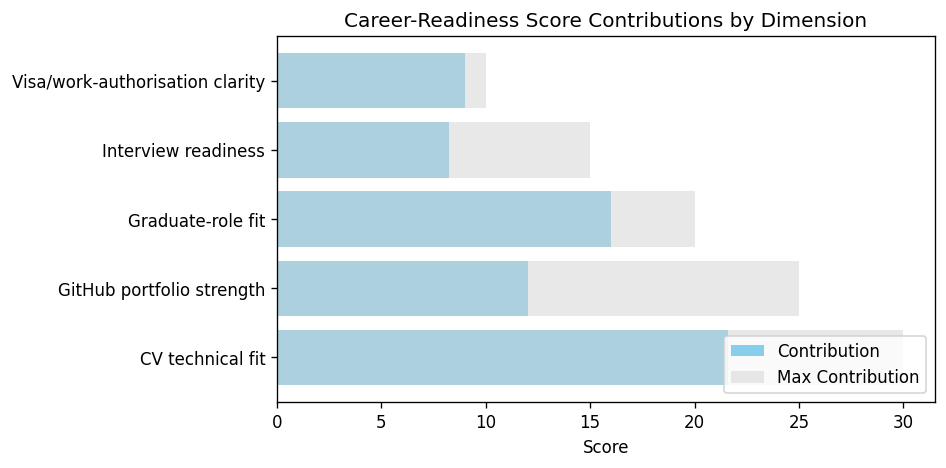

      🖼 rendered image: /content/readiness.png
  [iter 1] model returned final answer

Here is your quantitative Career-Readiness assessment using your self-supplied scores and the requested weighting:

### DataFrame Output

| Dimension                      | Raw | Weight | Contribution | MaxContribution |
|---------------------------------|-----|--------|--------------|-----------------|
| CV technical fit                | 72  | 0.30   | 21.60        | 30.00           |
| GitHub portfolio strength       | 48  | 0.25   | 12.00        | 25.00           |
| Graduate-role fit               | 80  | 0.20   | 16.00        | 20.00           |
| Interview readiness             | 55  | 0.15   | 8.25         | 15.00           |
| Visa/work-authorisation clarity | 90  | 0.10   | 9.00         | 10.00           |

**Total Career-Readiness Score:** 66.85 / 100

### Chart

You can download the chart here: [Download the Career-Readiness Chart (PNG)](sandbox:/mnt/data/readiness.png)

---

## Weakest Di

In [15]:
# ============================================================
# Worked Example 4 — force code_interpreter
# ============================================================


conversation_4 = []

user_msg_4 = (
    "I want a quantitative readiness assessment. Use code_interpreter to "
    "actually run Python code — print the DataFrame and save the chart as "
    "a PNG file (matplotlib).\n\n"
    "1. Take my self-assessment scores: "
    "CV technical fit = 72, GitHub portfolio strength = 48, "
    "graduate-role fit = 80, interview readiness = 55, "
    "visa/work-authorisation clarity = 90 (each out of 100).\n\n"
    "2. Apply this weighting:\n"
    "   - CV technical fit: 30%\n"
    "   - GitHub portfolio strength: 25%\n"
    "   - Graduate-role fit: 20%\n"
    "   - Interview readiness: 15%\n"
    "   - Visa/work-authorisation clarity: 10%\n\n"
    "3. Compute weighted contributions and the total Career-Readiness Score. "
    "Build a pandas DataFrame with columns: Dimension, Raw, Weight, Contribution, "
    "MaxContribution. Print it.\n\n"
    "4. Use matplotlib to plot a horizontal bar chart of contributions vs "
    "max-contribution per dimension. Save it with plt.savefig('readiness.png', "
    "dpi=120, bbox_inches='tight') and call plt.show().\n\n"
    "5. After the code runs, identify the two weakest dimensions by the ratio "
    "Contribution / MaxContribution and recommend a concrete next action for "
    "each, citing relevant rubric files from the knowledge base "
    "(`rubric_cv_scoring.md`, `rubric_github_portfolio_audit.md`)."
)

print('USER:')
print(user_msg_4)
print('\n' + '='*60)
print('AGENT:')
print('='*60)

# Force code_interpreter on the first iteration so the model can't skip it
answer_4, conversation_4 = run_agent_turn(
    conversation_4,
    user_msg_4,
    force_tool_first_iter={"type": "code_interpreter"}
)
print('\n' + answer_4)

---
## Section 11 · Worked Example 5 · Company-culture comparison via The Muse

**Scenario**: A user is choosing between two Dublin tech employers and wants up-to-date role context plus curated company knowledge.

**Expected tool path**: function call (`get_company_insights` for each company) → file search (curated company profiles) → final comparison.

This example exercises the third external API (The Muse), demonstrating that all three external APIs — Greenhouse, GitHub, The Muse — are actually invoked by the agent in real scenarios.

In [16]:
# ============================================================
# Worked Example 5 · Company-culture comparison via The Muse
# ============================================================

conversation_5 = []

user_msg_5 = (
    "I'm deciding whether to focus my next round of applications on Stripe "
    "or Squarespace, both in Dublin. "
    "Please:\n"
    "(1) Use `get_company_insights` to fetch current Dublin role / culture "
    "context from The Muse for both companies.\n"
    "(2) Cross-reference with the curated knowledge base — cite the "
    "`company_stripe_dublin.md` and `company_squarespace_dublin.md` files.\n"
    "(3) Give me a side-by-side comparison covering: tech stack, hiring "
    "process at graduate level, company culture signals, and which one "
    "is a stronger fit for a Java + Python Master's graduate.\n"
    "(4) End with a one-sentence recommendation."
)

print('USER:')
print(user_msg_5)
print('\n' + '='*60)
print('AGENT:')
print('='*60)

answer_5, conversation_5 = run_agent_turn(conversation_5, user_msg_5)
print('\n' + answer_5)

USER:
I'm deciding whether to focus my next round of applications on Stripe or Squarespace, both in Dublin. Please:
(1) Use `get_company_insights` to fetch current Dublin role / culture context from The Muse for both companies.
(2) Cross-reference with the curated knowledge base — cite the `company_stripe_dublin.md` and `company_squarespace_dublin.md` files.
(3) Give me a side-by-side comparison covering: tech stack, hiring process at graduate level, company culture signals, and which one is a stronger fit for a Java + Python Master's graduate.
(4) End with a one-sentence recommendation.

AGENT:

  [iter 1] calling model...
  [iter 1] model requested 1 function call(s)
      → get_company_insights({'company_name': 'Stripe'})

  [iter 2] calling model...
  [iter 2] model requested 1 function call(s)
      → get_company_insights({'company_name': 'Squarespace'})

  [iter 3] calling model...
      🔍 file_search: queries=['Stripe Dublin tech stack', 'Stripe Dublin graduate hiring process', 